
# Water

In [123]:
from pathlib import Path

import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import joblib
from google.colab import files

## EDA

In [124]:
path = kagglehub.dataset_download("uom190346a/water-quality-and-potability")
filepath = Path(path) / "water_potability.csv"

df = pd.read_csv(filepath)

df.columns = [c.replace(' ', '_') for c in df.columns]

df

Using Colab cache for faster access to the 'water-quality-and-potability' dataset.


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0
...,...,...,...,...,...,...,...,...,...,...
3271,4.668102,193.681735,47580.991603,7.166639,359.948574,526.424171,13.894419,66.687695,4.435821,1
3272,7.808856,193.553212,17329.802160,8.061362,NaN,392.449580,19.903225,NaN,2.798243,1
3273,9.419510,175.762646,33155.578218,7.350233,NaN,432.044783,11.039070,69.845400,3.298875,1
3274,5.126763,230.603758,11983.869376,6.303357,NaN,402.883113,11.168946,77.488213,4.708658,1


In [125]:
print('Dimensiones:', df.shape)
print('\nTipos de datos:')
print(df.dtypes)
print('\nPrimeras filas:')
df.head()

Dimensiones: (3276, 10)

Tipos de datos:
ph                 float64
Hardness           float64
Solids             float64
Chloramines        float64
Sulfate            float64
Conductivity       float64
Organic_carbon     float64
Trihalomethanes    float64
Turbidity          float64
Potability           int64
dtype: object

Primeras filas:


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [126]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ph,2785.0,7.080795,1.594320,0.000000,6.093092,7.036752,8.062066,14.000000
Hardness,3276.0,196.369496,32.879761,47.432000,176.850538,196.967627,216.667456,323.124000
Solids,3276.0,22014.092526,8768.570828,320.942611,15666.690297,20927.833607,27332.762127,61227.196008
Chloramines,3276.0,7.122277,1.583085,0.352000,6.127421,7.130299,8.114887,13.127000
Sulfate,2495.0,333.775777,41.416840,129.000000,307.699498,333.073546,359.950170,481.030642
Conductivity,3276.0,426.205111,80.824064,181.483754,365.734414,421.884968,481.792304,753.342620
Organic_carbon,3276.0,14.284970,3.308162,2.200000,12.065801,14.218338,16.557652,28.300000
Trihalomethanes,3114.0,66.396293,16.175008,0.738000,55.844536,66.622485,77.337473,124.000000
Turbidity,3276.0,3.966786,0.780382,1.450000,3.439711,3.955028,4.500320,6.739000
Potability,3276.0,0.390110,0.487849,0.000000,0.000000,0.000000,1.000000,1.000000


In [127]:
missing = df.isnull().sum()
print('Valores nulos por columna:')
print(missing)

Valores nulos por columna:
ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64


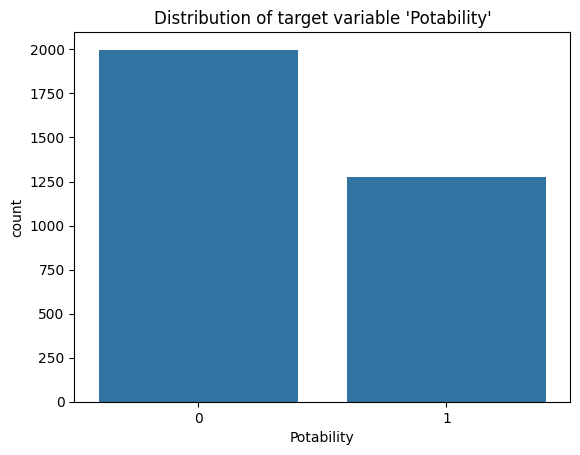

In [128]:
sns.countplot(data=df, x="Potability")
plt.title("Distribution of target variable 'Potability'")
plt.show()

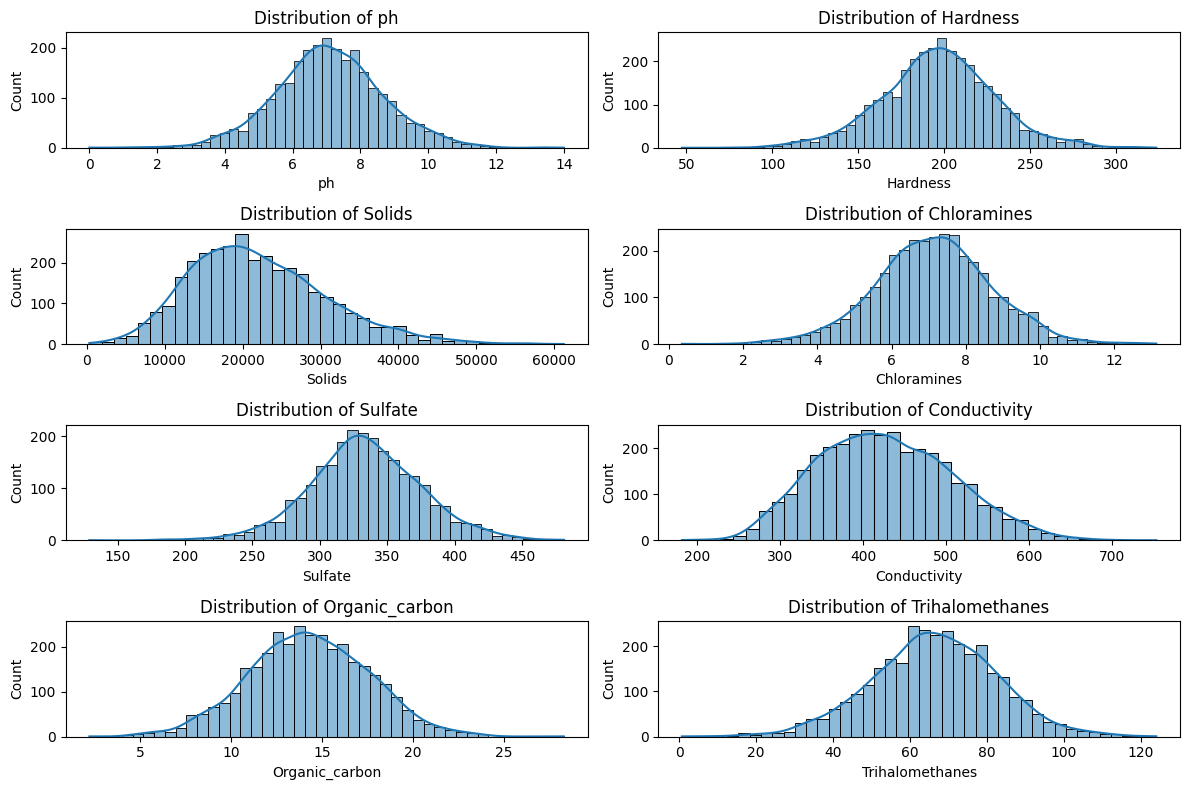

In [129]:
num_cols = ['ph','Hardness','Solids','Chloramines',
            'Sulfate','Conductivity','Organic_carbon','Trihalomethanes','Turbidity']

fig, axs = plt.subplots(4, 2, figsize=(12, 8))

for ax, col in zip(axs.ravel(), num_cols):
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(f'Distribution of {col}')

fig.tight_layout()

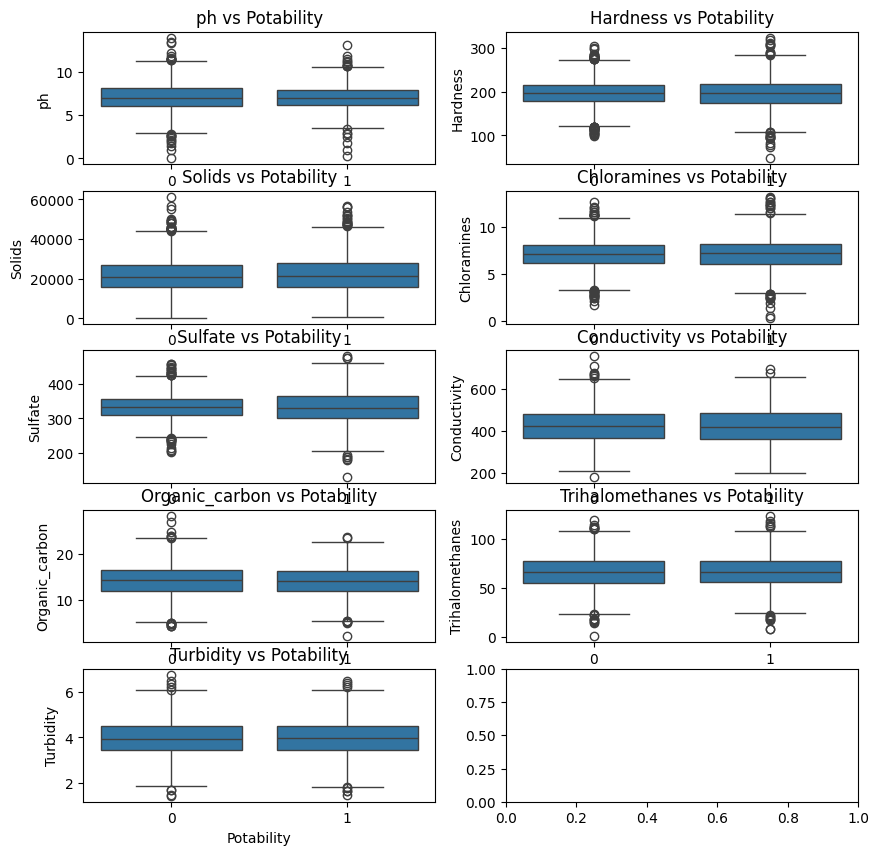

In [130]:
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(10, 10))

for ax, feature in zip(axes.ravel(), num_cols):
    sns.boxplot(data=df, x="Potability", y=feature, ax=ax)
    ax.set_title(f"{feature} vs Potability")

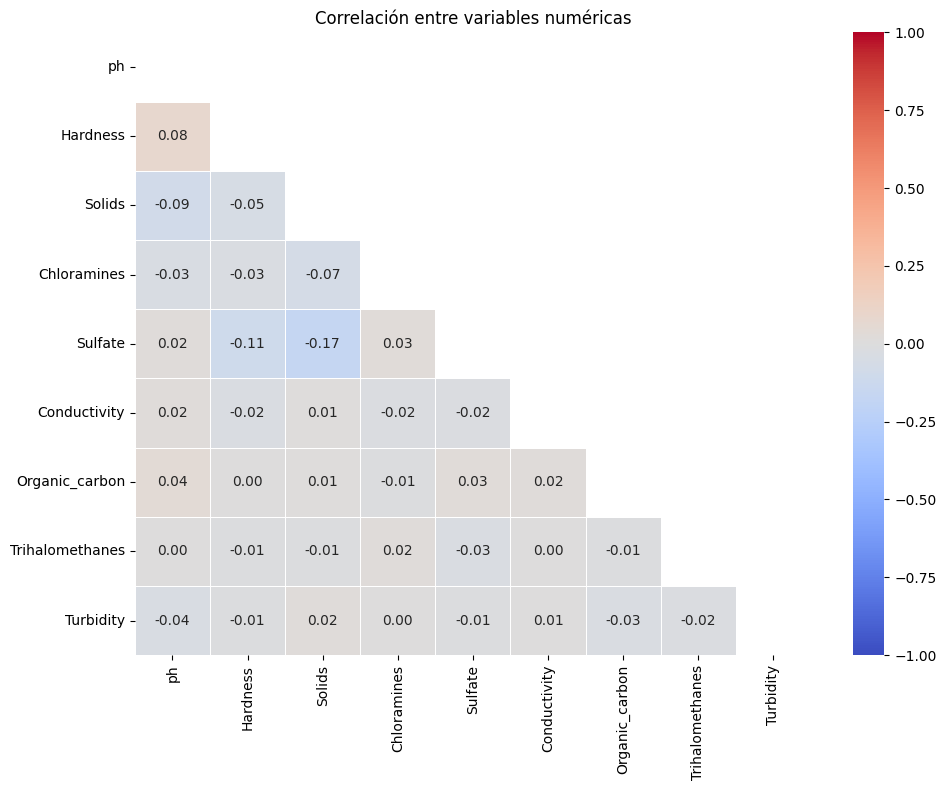

In [131]:
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, ax=ax, linewidths=0.5)
ax.set_title('Correlación entre variables numéricas')
plt.tight_layout()
plt.show()

## Preprocesamiento

In [132]:
num_features = ['ph', 'Hardness', 'Solids', 'Chloramines',
                'Sulfate', 'Conductivity', 'Organic_carbon',
                'Trihalomethanes', 'Turbidity']

preprocessing = make_pipeline(
    ColumnTransformer(
        transformers=[
            ('num', make_pipeline(
                SimpleImputer(strategy='median'),
                StandardScaler()
            ), num_features),
        ],
        remainder='passthrough',
        verbose_feature_names_out=False
    )
)

## Entrenamiento

In [133]:
x = df.drop(columns=['Potability'])
y = df['Potability']

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [134]:
X_train = preprocessing.fit_transform(X_train)
feature_names = preprocessing.named_steps['columntransformer'].get_feature_names_out()
X_train = pd.DataFrame(X_train, columns=feature_names)
X_train.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity
0,-0.311235,0.202046,-0.554634,-0.666527,-0.599837,-0.199296,0.506221,-0.085002,-1.341104
1,-0.269469,-0.080066,1.368736,1.743813,0.306595,0.882586,-1.654207,0.018387,0.090829
2,-0.165980,0.283021,-0.423990,-0.248791,-0.983558,0.838486,-0.134860,0.274308,1.274183
3,-0.039111,-0.397879,-1.063086,1.681607,-0.374831,0.690172,-0.286851,-1.231650,-0.923584
4,-0.459476,-0.416413,-0.477227,0.223520,-0.026279,-0.340518,0.928554,-0.145023,0.788260


In [135]:
X_test = preprocessing.transform(X_test)
X_test = pd.DataFrame(X_test, columns=feature_names)
X_test.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity
0,-0.039111,-0.396889,-0.181736,0.141929,-0.008798,-0.862984,1.804635,0.041143,1.189622
1,-0.297871,-0.231339,1.223451,-0.199252,0.011353,-1.106997,0.138518,0.093209,0.773151
2,0.524577,0.847637,0.135567,-0.746663,-0.912681,-0.473669,-0.257313,-1.470110,-1.889486
3,0.055824,-0.410145,-1.734696,-2.081479,-1.542685,0.019900,-1.355564,1.493748,-0.096291
4,-0.316884,-0.528300,0.489763,1.386439,-0.018756,0.861638,-0.446127,0.750703,0.633546


## Entrenamiento de modelos y evaluacion

In [136]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate_model(model, X, y):
    y_pred = model.predict(X)
    accuracy = accuracy_score(y, y_pred)
    precision = precision_score(y, y_pred, average='weighted')
    recall = recall_score(y, y_pred, average='weighted')
    f1 = f1_score(y, y_pred, average='weighted')

    return {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    }

#### Modelo 1 - [Regresión Logística]

In [137]:
param_grid_lr = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga'],
    'class_weight': [None, 'balanced']
}

grid_search = GridSearchCV(
    LogisticRegression(random_state=42, max_iter=5000),
    param_grid_lr,
    cv=5,
    scoring='f1_weighted',
    verbose=1
)

In [138]:
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 48 candidates, totalling 240 fits


GridSearchCV(cv=5, estimator=LogisticRegression(max_iter=5000, random_state=42),
             param_grid={'C': [0.001, 0.01, 0.1, 1, 10, 100],
                         'class_weight': [None, 'balanced'],
                         'penalty': ['l1', 'l2'],
                         'solver': ['liblinear', 'saga']},
             scoring='f1_weighted', verbose=1)

In [139]:
grid_search.best_params_

{'C': 0.001, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'saga'}

In [140]:
model_LR = grid_search.best_estimator_

train_metrics = evaluate_model(model_LR, X_train, y_train)
test_metrics = evaluate_model(model_LR, X_test, y_test)

metrics_df = pd.DataFrame({
    "Train": train_metrics,
    "Test": test_metrics})
metrics_df.T

,Accuracy,Precision,Recall,F1-Score
Train,0.516031,0.532992,0.516031,0.521200
Test,0.503049,0.534276,0.503049,0.511328


#### Modelo 2 - [SVC]

In [141]:
param_grid_svm = {
    'C': [0.01, 0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1],
    'degree': [2, 3, 4],
    'class_weight': [None, 'balanced'],
}

grid_svm = GridSearchCV(
    SVC(random_state=42),
    param_grid_svm,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

In [142]:
grid_svm.fit(X_train, y_train)

Fitting 5 folds for each of 150 candidates, totalling 750 fits


GridSearchCV(cv=5, estimator=SVC(random_state=42), n_jobs=-1,
             param_grid={'C': [0.01, 0.1, 1, 10, 100],
                         'class_weight': [None, 'balanced'],
                         'degree': [2, 3, 4],
                         'gamma': ['scale', 'auto', 0.001, 0.01, 0.1]},
             scoring='f1_weighted', verbose=1)

In [143]:
grid_svm.best_params_

{'C': 1, 'class_weight': 'balanced', 'degree': 2, 'gamma': 'auto'}

In [144]:
model_SVM = grid_svm.best_estimator_

train_metrics = evaluate_model(model_SVM, X_train, y_train)
test_metrics = evaluate_model(model_SVM, X_test, y_test)

metrics_df = pd.DataFrame({
    "Train": train_metrics,
    "Test": test_metrics})
metrics_df.T

,Accuracy,Precision,Recall,F1-Score
Train,0.752672,0.751968,0.752672,0.752284
Test,0.638720,0.640876,0.638720,0.639726


#### Modelo 3 - [Classificador de Bosque Aleatorio]

In [145]:

from sklearn.model_selection import GridSearchCV

from sklearn.ensemble import RandomForestClassifier

param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [5, 8],
    'min_samples_split': [10, 20],
    'min_samples_leaf': [4, 8],
    'class_weight': ['balanced'],
    'max_features': ['sqrt']
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

In [146]:
grid_rf.fit(X_train, y_train)

Fitting 5 folds for each of 16 candidates, totalling 80 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'class_weight': ['balanced'], 'max_depth': [5, 8],
                         'max_features': ['sqrt'], 'min_samples_leaf': [4, 8],
                         'min_samples_split': [10, 20],
                         'n_estimators': [100, 200]},
             scoring='f1_weighted', verbose=1)

In [147]:
grid_rf.best_params_

{'class_weight': 'balanced',
 'max_depth': 8,
 'max_features': 'sqrt',
 'min_samples_leaf': 4,
 'min_samples_split': 20,
 'n_estimators': 100}

In [148]:
model_RF = grid_rf.best_estimator_

train = evaluate_model(model_RF, X_train, y_train)
test = evaluate_model(model_RF, X_test, y_test)

metrics_df = pd.DataFrame({
    "Train": train,
    "Test": test})
metrics_df.T

,Accuracy,Precision,Recall,F1-Score
Train,0.823664,0.824718,0.823664,0.820045
Test,0.664634,0.655270,0.664634,0.657426


## Evaluacion final

In [149]:
results = []

metrics_lr = evaluate_model(model_LR, X_test, y_test)
results.append({'Model': 'Logistic Regression', **metrics_lr})
print(f"\nLogistic Regression:")
print(f"  Accuracy:  {metrics_lr['Accuracy']:.4f}")
print(f"  Precision: {metrics_lr['Precision']:.4f}")
print(f"  Recall:    {metrics_lr['Recall']:.4f}")
print(f"  F1-Score:  {metrics_lr['F1-Score']:.4f}")

metrics_svm = evaluate_model(model_SVM, X_test, y_test)
results.append({'Model': 'SVM', **metrics_svm})
print(f"\nSVM:")
print(f"  Accuracy:  {metrics_svm['Accuracy']:.4f}")
print(f"  Precision: {metrics_svm['Precision']:.4f}")
print(f"  Recall:    {metrics_svm['Recall']:.4f}")
print(f"  F1-Score:  {metrics_svm['F1-Score']:.4f}")

metrics_svm = evaluate_model(model_RF, X_test, y_test)
results.append({'Model': 'RF', **metrics_svm})
print(f"\nRF:")
print(f"  Accuracy:  {metrics_svm['Accuracy']:.4f}")
print(f"  Precision: {metrics_svm['Precision']:.4f}")
print(f"  Recall:    {metrics_svm['Recall']:.4f}")
print(f"  F1-Score:  {metrics_svm['F1-Score']:.4f}")


comparison_df = pd.DataFrame(results)
comparison_df = comparison_df.set_index('Model')
print(comparison_df)


Logistic Regression:
  Accuracy:  0.5030
  Precision: 0.5343
  Recall:    0.5030
  F1-Score:  0.5113

SVM:
  Accuracy:  0.6387
  Precision: 0.6409
  Recall:    0.6387
  F1-Score:  0.6397

RF:
  Accuracy:  0.6646
  Precision: 0.6553
  Recall:    0.6646
  F1-Score:  0.6574
                     Accuracy  Precision    Recall  F1-Score
Model                                                       
Logistic Regression  0.503049   0.534276  0.503049  0.511328
SVM                  0.638720   0.640876  0.638720  0.639726
RF                   0.664634   0.655270  0.664634  0.657426


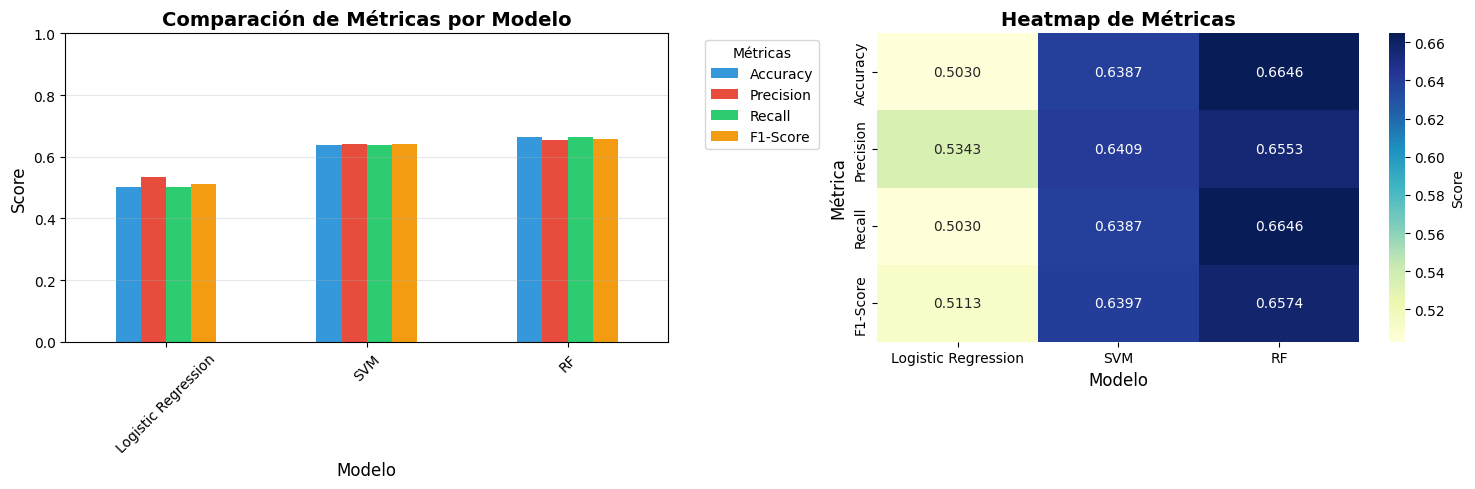

In [150]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

comparison_df.plot(kind='bar', ax=axes[0], rot=45, color=['#3498db', '#e74c3c', '#2ecc71', '#f39c12'])
axes[0].set_title('Comparación de Métricas por Modelo', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Score', fontsize=12)
axes[0].set_xlabel('Modelo', fontsize=12)
axes[0].legend(title='Métricas', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_ylim(0, 1)

sns.heatmap(comparison_df.T, annot=True, fmt='.4f', cmap='YlGnBu',
            ax=axes[1], cbar_kws={'label': 'Score'})
axes[1].set_title('Heatmap de Métricas', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Modelo', fontsize=12)
axes[1].set_ylabel('Métrica', fontsize=12)

plt.tight_layout()
plt.show()

## Analisis del mejor modelo

In [151]:
best_model_name = comparison_df['Accuracy'].idxmax()
best_accuracy = comparison_df['Accuracy'].max()

print(f"\nMejor modelo: {best_model_name}")
print(f"Accuracy: {best_accuracy:.4f}")

if best_model_name == 'SVM':
    best_model = model_SVM
else:
    best_model = model_RF

print(f"\nMétricas:")
print(f"  Accuracy:  {comparison_df.loc[best_model_name, 'Accuracy']:.4f}")
print(f"  Precision: {comparison_df.loc[best_model_name, 'Precision']:.4f}")
print(f"  Recall:    {comparison_df.loc[best_model_name, 'Recall']:.4f}")
print(f"  F1-Score:  {comparison_df.loc[best_model_name, 'F1-Score']:.4f}")


Mejor modelo: RF
Accuracy: 0.6646

Métricas:
  Accuracy:  0.6646
  Precision: 0.6553
  Recall:    0.6646
  F1-Score:  0.6574


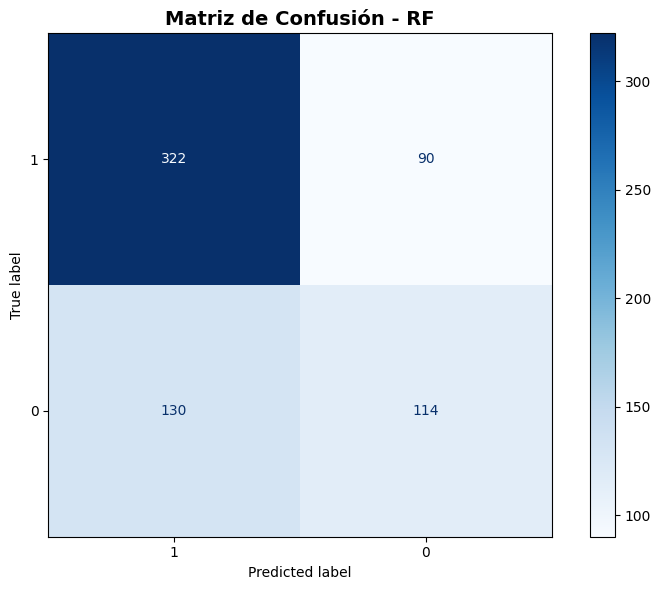

In [152]:
y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['1', '0'])
disp.plot(cmap='Blues', ax=ax, values_format='d')
ax.set_title(f'Matriz de Confusión - {best_model_name}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [153]:
report = classification_report(y_test, y_pred_best)
print(report)

              precision    recall  f1-score   support

           0       0.71      0.78      0.75       412
           1       0.56      0.47      0.51       244

    accuracy                           0.66       656
   macro avg       0.64      0.62      0.63       656
weighted avg       0.66      0.66      0.66       656



## Serialización con JobLib

In [154]:
best_model = model_RF
final_pipeline = Pipeline([
    ("preprocessing", preprocessing),
    ("model", best_model)
])

final_pipeline.fit(x, y)

joblib.dump(final_pipeline, "modelo_agua1.joblib")
files.download("modelo_agua1.joblib")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>